In [7]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".*anndata.*", category=FutureWarning)

# - dirs 
from ciim.src.common import datasets_all, aging_clock_train_datasets, aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.feature_association.helper import retrieve_sig_stats

from ciim.src.utils.util import get_genesets, retrieve_adata_bulk

reg_type = 'ridge'
version = 'v1.0'
data_type = 'bulk'

simulation_iteration = 3
n_donors = 20

cell_types = ['CD8T'] #['CD4T', 'CD8T',  'NK', 'MONO']

In [29]:
from scvi.model.base import BaseModelClass
from scvi.model import SCVI
from torch import nn
import torch

class SCVIAgePredictor(SCVI):
    def __init__(self, adata, n_hidden = 128, **kwargs):
        super().__init__(adata, **kwargs)

        # Add MLP regression head for age prediction
        self.module.age_predictor = nn.Sequential(
            nn.Linear(self.module.n_latent, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, 1)
        )

    def forward(self, *args, **kwargs):
        # Run base model
        outputs = super().forward(*args, **kwargs)
        z = outputs["z"]
        
        # Predict age
        age_pred = self.module.age_predictor(z)
        outputs["age_pred"] = age_pred
        return outputs

    def loss(self, tensors, inference_outputs, generative_outputs):
        # Get base model loss
        base_loss = super().loss(tensors, inference_outputs, generative_outputs)
        
        # Add supervised age prediction loss (e.g. MSE)
        age_true = tensors["age"].unsqueeze(1)
        age_pred = inference_outputs["age_pred"]
        age_loss = torch.nn.functional.mse_loss(age_pred, age_true, reduction="mean")
        
        # Combine losses
        total_loss = base_loss["loss"] + self.age_loss_weight * age_loss
        base_loss["loss"] = total_loss
        base_loss["age_loss"] = age_loss
        return base_loss
    def predict_age(self, adata):
        self.module.eval()
        latent = self.get_latent_representation(adata)
        with torch.no_grad():
            age_pred = self.module.age_predictor(torch.tensor(latent).to(self.module.age_predictor[0].weight.device)).cpu().numpy().flatten()
        return age_pred

In [33]:
adata = ad.read_h5ad('/vol/projects/jnourisa/datasets/data12_sc.h5ad')
# adata = retrieve_adata_bulk(dataset='data12')

In [ ]:
sc.pp.filter_cells(adata, max_counts=20000)
sc.pp.filter_genes(adata, min_counts=5)

In [34]:
from scvi.model import SCVI
SCVIAgePredictor.setup_anndata(
    adata,
    batch_key="dataset",  # or your batch variable
    continuous_covariate_keys=["age"]
)
model = SCVIAgePredictor(adata)
model.age_loss_weight = 1.0
model.train(max_epochs=400)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/400:   0%|          | 0/400 [00:00<?, ?it/s]

ValueError: Expected parameter loc (Tensor of shape (128, 10)) of distribution Normal(loc: torch.Size([128, 10]), scale: torch.Size([128, 10])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [31]:
age_pred = model.predict_age(adata)

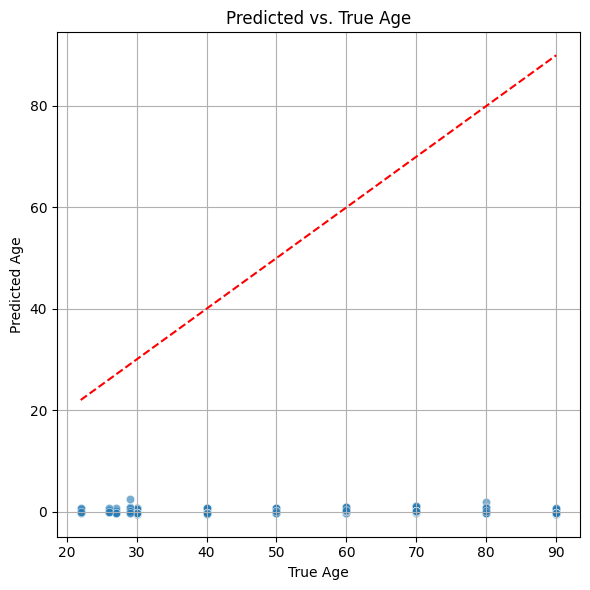

In [32]:
true_age = adata.obs["age"].values
true_age = pd.to_numeric(true_age)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(6, 6))
sns.scatterplot(x=true_age, y=age_pred, alpha=0.6)
plt.plot([true_age.min(), true_age.max()], [true_age.min(), true_age.max()], 'r--')
plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs. True Age")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Process new data
from scvi.data import transfer_anndata_setup
new_adata = transfer_anndata_setup(new_adata, adata)  # Aligns structure

# Load model and predict
model_new = SCVIAgePredictor.load(saved_model_path, new_adata)
age_predictions = model_new.get_latents()  # or model_new.module.age_predictor(z)